# Battery MLP — Depth Comparison (v4)

Reuses the feature/target pipeline from `training_v3.ipynb` (charge(k+1) as observed input, `safe_discharge_ah` as the direct target) unchanged.
Adds a **configurable MLP** (`ConfigurableMLP`) so different depths can be trained and compared against the v3 baseline (`[32, 16]`, 2 hidden layers) on equal footing: same data, same scaler, same optimizer/epochs.


In [1]:
import os
import scipy.io
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

In [2]:
def extract_cumulative_capacity_dataset(mat_file_path, target_v_cutoff=3.0):
    mat = scipy.io.loadmat(mat_file_path)
    filename = os.path.splitext(os.path.basename(mat_file_path))[0]
    cycles = mat[filename][0, 0]['cycle'][0]

    rows = []
    current_charge_features = None
    running_cumulative_capacity = 0.0

    for c in cycles:
        c_type = c['type'][0]
        data = c['data'][0, 0]

        if c_type == 'charge':
            try:
                t_arr = data['Time'][0]
                i_arr = data['Current_measured'][0]
                temp_arr = data['Temperature_measured'][0]

                dt = np.diff(t_arr)
                avg_i = (i_arr[:-1] + i_arr[1:]) / 2
                total_charge_in = np.sum(avg_i * dt) / 3600.0

                current_charge_features = {
                    'charge_in_ah': total_charge_in,
                    'charge_max_temp': np.max(temp_arr),
                    'charge_duration': t_arr[-1] - t_arr[0],
                }
            except Exception:
                current_charge_features = None

        elif c_type == 'discharge' and current_charge_features is not None:
            try:
                v_arr = data['Voltage_measured'][0]
                i_arr = data['Current_measured'][0]
                t_arr = data['Time'][0]

                safe_idx = np.where(v_arr >= target_v_cutoff)[0]

                if len(safe_idx) > 1:
                    i_trunc = np.abs(i_arr[safe_idx])
                    t_trunc = t_arr[safe_idx]
                    dt = np.diff(t_trunc)
                    avg_i = (i_trunc[:-1] + i_trunc[1:]) / 2
                    safe_discharge_ah = np.sum(avg_i * dt) / 3600.0

                    running_cumulative_capacity += safe_discharge_ah

                    rows.append({
                        'charge_in_ah': current_charge_features['charge_in_ah'],
                        'charge_max_temp': current_charge_features['charge_max_temp'],
                        'charge_duration': current_charge_features['charge_duration'],
                        'safe_discharge_ah': safe_discharge_ah,
                        'cumulative_capacity_ah': running_cumulative_capacity,
                    })

                current_charge_features = None
            except Exception:
                current_charge_features = None
                continue

    return pd.DataFrame(rows)

def prepare_mlp_delta_features(df):
    df_mlp = df.copy()
    df_mlp['prev_cumulative_capacity_ah'] = df_mlp['cumulative_capacity_ah'].shift(1).fillna(0.0)

    feature_cols = [
        'charge_in_ah',
        'charge_max_temp',
        'charge_duration',
        'prev_cumulative_capacity_ah'
    ]

    target_col = 'safe_discharge_ah'

    return df_mlp[feature_cols], df_mlp[[target_col]]

In [3]:
class BatteryMLPDataset(Dataset):
    def __init__(self, X_numpy, y_numpy):
        self.X = torch.tensor(X_numpy, dtype=torch.float32)
        self.y = torch.tensor(y_numpy, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [4]:
df_b0005 = extract_cumulative_capacity_dataset('Data/B0005.mat', 2.7)
df_b0006 = extract_cumulative_capacity_dataset('Data/B0006.mat', 2.5)
df_b0007 = extract_cumulative_capacity_dataset('Data/B0007.mat', 2.2)

X_b0005, y_b0005 = prepare_mlp_delta_features(df_b0005)
X_b0006, y_b0006 = prepare_mlp_delta_features(df_b0006)
X_b0007, y_b0007 = prepare_mlp_delta_features(df_b0007)

X_train_raw = pd.concat([X_b0005, X_b0006], axis=0)
scaler = StandardScaler().fit(X_train_raw)

X_train_scaled = np.concatenate([scaler.transform(X_b0005), scaler.transform(X_b0006)], axis=0)
y_train_final = np.concatenate([y_b0005.values, y_b0006.values], axis=0)

train_dataset = BatteryMLPDataset(X_train_scaled, y_train_final)
test_dataset = BatteryMLPDataset(scaler.transform(X_b0007), y_b0007.values)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

print(f"Train samples: {len(train_dataset)}")
print(f"Test samples:  {len(test_dataset)}")

Train samples: 334
Test samples:  167


## Configurable MLP

`hidden_dims` is a list of hidden-layer widths only (e.g. `[32, 16]` = 2 hidden layers). The input dimension (4 features) and the output layer (1 neuron, regression) are fixed automatically — you never specify them.


In [5]:
class ConfigurableMLP(nn.Module):
    """
    MLP with a configurable number/width of hidden layers.

    hidden_dims : list[int]
        Hidden layer widths only, e.g. [32, 16] -> 2 hidden layers of size 32 then 16.
        Input dim and the final output layer (1 neuron, regression) are fixed automatically.
    """
    def __init__(self, input_dim=4, hidden_dims=(32, 16)):
        super(ConfigurableMLP, self).__init__()
        layers = []
        prev_dim = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.ReLU())
            prev_dim = h
        layers.append(nn.Linear(prev_dim, 1))  # regression output, no activation
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

# Sanity check: this should reproduce the training_v3.ipynb baseline exactly
print(ConfigurableMLP(input_dim=4, hidden_dims=[32, 16]))

ConfigurableMLP(
  (network): Sequential(
    (0): Linear(in_features=4, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
  )
)


In [6]:
def count_params(model):
    return sum(p.numel() for p in model.parameters())


def train_and_evaluate(hidden_dims, epochs=50, lr=0.005, verbose=False):
    """
    Builds a ConfigurableMLP with the given hidden_dims, trains it on
    train_loader, evaluates it on test_loader (Battery B0007, unseen),
    and returns a dict of results for comparison.
    """
    torch.manual_seed(42)  # same init seed for every architecture -> fair comparison

    model = ConfigurableMLP(input_dim=4, hidden_dims=hidden_dims)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * batch_X.size(0)
        epoch_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_loss)
        if verbose and ((epoch + 1) % 10 == 0 or epoch == 0):
            print(f"  {list(hidden_dims)} | Epoch [{epoch+1}/{epochs}] Train MSE: {epoch_loss:.6f}")

    model.eval()
    preds, actuals = [], []
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            pred = model(batch_X)
            preds.append(pred.item())
            actuals.append(batch_y.item())
    preds = np.array(preds)
    actuals = np.array(actuals)
    test_mse = float(np.mean((preds - actuals) ** 2))

    return {
        'hidden_dims': list(hidden_dims),
        'n_hidden_layers': len(hidden_dims),
        'n_params': count_params(model),
        'final_train_mse': train_losses[-1],
        'test_mse': test_mse,
        'train_losses': train_losses,
        'model': model,
        'test_preds': preds,
        'test_actuals': actuals,
    }

## Depth comparison sweep

Baseline `[32, 16]` matches `training_v3.ipynb` exactly. The rest add depth (3, 4, 5 hidden layers) while keeping widths reasonable (never below 4) to avoid the underfitting risk of very narrow deep nets on a ~330-sample training set.


In [7]:
architectures = [
    [32, 16],             # baseline (matches training_v3.ipynb)
    [32, 16, 8],           # 3 hidden layers
    [32, 16, 8, 8],        # 4 hidden layers
    [32, 32, 16, 8, 4],    # 5 hidden layers
]

results = []
for arch in architectures:
    print(f"Training architecture: {arch}")
    res = train_and_evaluate(arch, epochs=50, lr=0.005, verbose=False)
    results.append(res)
    print(f"  -> params={res['n_params']}, train_mse={res['final_train_mse']:.6f}, test_mse={res['test_mse']:.6f}\n")

Training architecture: [32, 16]
  -> params=705, train_mse=0.000617, test_mse=0.000671

Training architecture: [32, 16, 8]
  -> params=833, train_mse=0.000425, test_mse=0.000778

Training architecture: [32, 16, 8, 8]
  -> params=905, train_mse=0.000393, test_mse=0.002420

Training architecture: [32, 32, 16, 8, 4]
  -> params=1921, train_mse=0.000583, test_mse=0.001975



In [8]:
results_df = pd.DataFrame([
    {
        'hidden_dims': r['hidden_dims'],
        'n_hidden_layers': r['n_hidden_layers'],
        'n_params': r['n_params'],
        'final_train_mse': r['final_train_mse'],
        'test_mse': r['test_mse'],
    }
    for r in results
]).sort_values('test_mse').reset_index(drop=True)

results_df

,hidden_dims,n_hidden_layers,n_params,final_train_mse,test_mse
0,"[32, 16]",2,705,0.000617,0.000671
1,"[32, 16, 8]",3,833,0.000425,0.000778
2,"[32, 32, 16, 8, 4]",5,1921,0.000583,0.001975
3,"[32, 16, 8, 8]",4,905,0.000393,0.002420


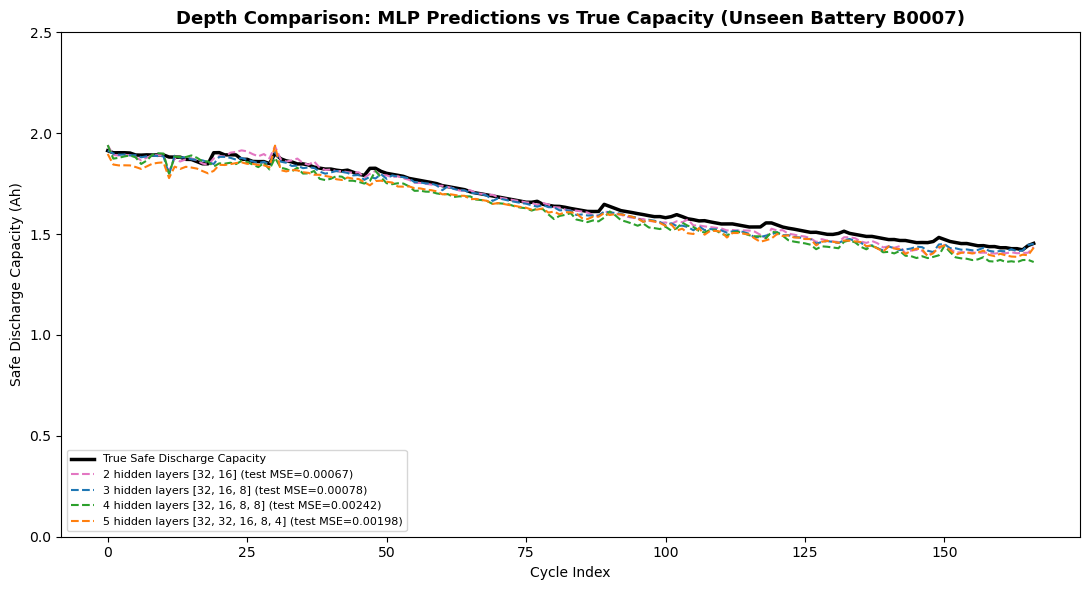

In [9]:
plt.figure(figsize=(11, 6), dpi=100)
plt.plot(results[0]['test_actuals'], label='True Safe Discharge Capacity', color='black', lw=2.5)

colors = ['#e377c2', '#1f77b4', '#2ca02c', '#ff7f0e', '#9467bd']
for i, r in enumerate(results):
    label = f"{r['n_hidden_layers']} hidden layers {r['hidden_dims']} (test MSE={r['test_mse']:.5f})"
    plt.plot(r['test_preds'], label=label, linestyle='--', lw=1.5, color=colors[i % len(colors)])

plt.title('Depth Comparison: MLP Predictions vs True Capacity (Unseen Battery B0007)', fontsize=13, fontweight='bold')
plt.xlabel('Cycle Index')
plt.ylabel('Safe Discharge Capacity (Ah)')
plt.ylim(0, 2.5)
plt.legend(loc='lower left', fontsize=8, frameon=True)
plt.tight_layout()
plt.show()